## **IMPORTING**

In [ ]:
!pip install gensim
import nltk

import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Flatten, InputLayer, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer

import nltk
import re

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

import gensim
from gensim.models import Word2Vec
from tensorflow.keras.preprocessing.sequence import pad_sequences

import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 39.8 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


## **DATA CLEANING**

In [ ]:
df=pd.read_csv("/content/social_media_virality_10000.csv")

In [ ]:
df.head()

,post_id,caption_text,topic,hashtags_count,post_length,likes,shares,comments,is_viral
0,1,hard work always pays off,tech,8,254,13040,2576,4363,0
1,2,hard work always pays off,education,8,163,27166,9011,1899,1
2,3,hard work always pays off,NaN,10,67,23785,1074,728,1
3,4,learning ai is the future,news,5,80,5086,6724,1149,1
4,5,stay consistent and grow,meme,0,280,33801,5569,5407,0


In [ ]:
df.isnull().sum()

,0
post_id,0
caption_text,1370
topic,1668
hashtags_count,0
post_length,0
likes,0
shares,0
comments,0
is_viral,0


In [ ]:
df['topic']=df['topic'].fillna('empty')
df['caption_text']=df['caption_text'].fillna('empty')

In [ ]:
df.isnull().sum()

,0
post_id,0
caption_text,0
topic,0
hashtags_count,0
post_length,0
likes,0
shares,0
comments,0
is_viral,0


In [ ]:
df.head()

,post_id,caption_text,topic,hashtags_count,post_length,likes,shares,comments,is_viral
0,1,hard work always pays off,tech,8,254,13040,2576,4363,0
1,2,hard work always pays off,education,8,163,27166,9011,1899,1
2,3,hard work always pays off,empty,10,67,23785,1074,728,1
3,4,learning ai is the future,news,5,80,5086,6724,1149,1
4,5,stay consistent and grow,meme,0,280,33801,5569,5407,0


## **NLP + DEEP LEARNING**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf=TfidfVectorizer()

In [ ]:
tf=tfidf.fit_transform(df['topic'])
tf.shape

(10000, 6)

In [ ]:
df['new_topic']=list(tf.toarray())

In [ ]:
df.head()

,post_id,caption_text,topic,hashtags_count,post_length,likes,shares,comments,is_viral,new_topic
0,1,hard work always pays off,tech,8,254,13040,2576,4363,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]"
1,2,hard work always pays off,education,8,163,27166,9011,1899,1,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
2,3,hard work always pays off,empty,10,67,23785,1074,728,1,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0]"
3,4,learning ai is the future,news,5,80,5086,6724,1149,1,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0]"
4,5,stay consistent and grow,meme,0,280,33801,5569,5407,0,"[0.0, 0.0, 1.0, 0.0, 0.0, 0.0]"


In [ ]:
df.tail()

,post_id,caption_text,topic,hashtags_count,post_length,likes,shares,comments,is_viral,new_topic
9995,9996,coding memes are funny,tech,6,44,45638,7217,4686,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]"
9996,9997,this post will change your life,education,6,177,48904,2722,259,1,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
9997,9998,stay consistent and grow,motivation,13,6,39217,3150,5007,1,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0]"
9998,9999,stay consistent and grow,empty,3,260,25786,7529,6888,0,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0]"
9999,10000,empty,news,5,244,27823,9179,6778,0,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0]"


In [ ]:
corpus=[]

for sentence in df['caption_text']:
  sentence=re.sub('[^a-zA-Z]',' ',sentence)
  sentence=sentence.lower()
  words=sentence.split()
  words = [ps.stem(w) for w in words if w not in stop_words]
  corpus.append(words)

In [ ]:
tokenizer=Tokenizer()
tokenizer.fit_on_texts(corpus)

total_words=len(tokenizer.word_index)+1

input_sequences=[]

for line in corpus:
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        input_sequences.append(token_list[:i+1])

max_len=max(len(x) for x in input_sequences)

x_pad=pad_sequences(input_sequences,maxlen=max_len)

x=x_pad[ : , :-1]
y=x_pad[: , -1]

model=Sequential()
model.add(Embedding(total_words,15,input_length=max_len-1))
model.add(LSTM(64))
model.add(Dense(16, activation='relu'))
model.add(Dense(total_words, activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

model.fit(x,y, epochs=10)

first_words='the post will'
pred_words=3

for _ in range(pred_words):
  index=tokenizer.texts_to_sequences([first_words])
  pad=pad_sequences(index, maxlen=max_len-1)
  pred=model.predict(pad, verbose=0).argmax()
  first_words= first_words + ' ' + tokenizer.index_word[pred]

print(first_words)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
584/584 ━━━━━━━━━━━━━━━━━━━━ 14s 13ms/step - accuracy: 0.5576 - loss: 1.4904
Epoch 2/10
584/584 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 1.0000 - loss: 0.0037
Epoch 3/10
584/584 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 1.0000 - loss: 0.0010
Epoch 4/10
584/584 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 1.0000 - loss: 4.5378e-04
Epoch 5/10
584/584 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 1.0000 - loss: 2.4715e-04
Epoch 6/10
584/584 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 1.0000 - loss: 1.4837e-04
Epoch 7/10
584/584 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 1.0000 - loss: 9.4702e-05
Epoch 8/10
584/584 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 1.0000 - loss: 6.2892e-05
Epoch 9/10
584/584 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 1.0000 - loss: 4.2546e-05
Epoch 10/10
584/584 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 1.0000 - loss: 2.9432e-05
the post will chang life life


## **SUPERVISED ML**

In [ ]:
df.head(2)

,post_id,caption_text,topic,hashtags_count,post_length,likes,shares,comments,is_viral,new_topic
0,1,hard work always pays off,tech,8,254,13040,2576,4363,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]"
1,2,hard work always pays off,education,8,163,27166,9011,1899,1,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"


In [ ]:
x_cap_text=tfidf.fit_transform(df['caption_text'])
df['x_text']=list(x_cap_text.toarray())

x_captions=np.stack(df['x_text'].values)
x_topics=np.stack(df['new_topic'].values)
x_direct=df[['likes','shares','comments','hashtags_count']]
y=df['is_viral']

std=StandardScaler()
x_direct_std=std.fit_transform(x_direct)

x=np.concatenate((x_captions, x_topics, x_direct_std),axis=1)

from xgboost import XGBClassifier

model = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=42)

x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.3)

kf=StratifiedKFold(n_splits=5)
y_pred_cv_train=cross_val_predict(model,x_train,y_train,cv=kf)

model.fit(x_train,y_train)

y_test_pred=model.predict(x_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix

acc=accuracy_score(y_test,y_test_pred)
pres=precision_score(y_test,y_test_pred)
recall=recall_score(y_test,y_test_pred)
classi=classification_report(y_test,y_test_pred)
conf=confusion_matrix(y_test,y_test_pred)

print(acc)
print(pres)
print(recall)
print(classi)
print(conf)

0.5
0.5039432176656151
0.42317880794701984
              precision    recall  f1-score   support

           0       0.50      0.58      0.53      1490
           1       0.50      0.42      0.46      1510

    accuracy                           0.50      3000
   macro avg       0.50      0.50      0.50      3000
weighted avg       0.50      0.50      0.50      3000

[[861 629]
 [871 639]]


## **UNSUPERVISED ML**

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

x=np.stack(df['new_topic'].values)

model=DBSCAN(eps=0.5, min_samples=5)

std_sc=StandardScaler()
x_std=std_sc.fit_transform(x)

labels=model.fit_predict(x_std)

df['clusters']=labels

sih=silhouette_score(x_std,labels)

print(sih)

1.0


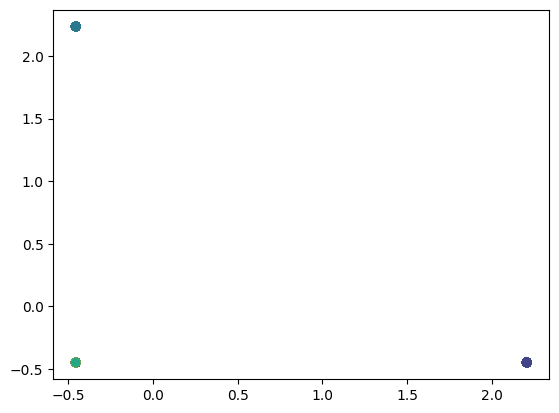

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(x_std[:, 0], x_std[:, 1], c=labels)

In [ ]:
df.head(2)

,post_id,caption_text,topic,hashtags_count,post_length,likes,shares,comments,is_viral,new_topic,x_text,clusters
0,1,hard work always pays off,tech,8,254,13040,2576,4363,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]","[0.0, 0.4472135954999579, 0.0, 0.0, 0.0, 0.0, ...",0
1,2,hard work always pays off,education,8,163,27166,9011,1899,1,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]","[0.0, 0.4472135954999579, 0.0, 0.0, 0.0, 0.0, ...",1


In [ ]:
clst=df['clusters'].value_counts().sort_index()
print(clst)

clusters
0    1643
1    1707
2    1668
3    1681
4    1654
5    1647
Name: count, dtype: int64


In [ ]:
df['clusters'].value_counts(normalize=True)*100

,proportion
clusters,
1,17.07
3,16.81
2,16.68
4,16.54
5,16.47
0,16.43


In [ ]:
df.groupby('clusters')['is_viral'].mean()*100

,is_viral
clusters,
0,49.908704
1,48.974810
2,47.841727
3,48.899465
4,49.455865
5,48.816029
